Plotting zonalmean MSEsfc change for SSP585-vs-HIST and G6sulfur-vs-SSP245

The idea is to show that MSE change is significant for SSP585-vs-HIST
But it is not significant in G6sulfur-vs-SSP245

It means, the argument of Bombardi-Boos is not applicable to study monsoon response in G6sulfur

In [1]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# User-defined metadata
# =========================

#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    "piControl": {"project": "CMIP",        "scenario": "piControl"},
    "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

In [2]:
%store -r all_results_585_HIST
%store -r all_results_G6sulfur_585
%store -r all_results_G6sulfur_245

#These variables were stored in https://notebooks.jasmin.ac.uk/user/bidyut/lab/workspaces/auto-r/tree/UoE/20260218_Monsoons/20260312_MSEsfc_Change_Map.ipynb
#manually changing the experiment name and accordingly changing the name of the variable to be stored.

In [3]:
# Compute all dask arrays within the nested structure
import dask

all_results_585_HIST = dask.compute(all_results_585_HIST)[0]
all_results_G6sulfur_585 = dask.compute(all_results_G6sulfur_585)[0]
all_results_G6sulfur_245 = dask.compute(all_results_G6sulfur_245)[0]

## check which one is faster : the cell above or the cell below (Ans: Above; commenting the cell below)

In [4]:
# def compute_nested(obj):
#     """Recursively compute all dask arrays in nested structure."""
#     import dask.array as da
#     import xarray as xr
    
#     if isinstance(obj, da.Array):
#         return obj.compute()
#     elif isinstance(obj, xr.DataArray) or isinstance(obj, xr.Dataset):
#         return obj.compute()
#     elif isinstance(obj, dict):
#         return {k: compute_nested(v) for k, v in obj.items()}
#     elif isinstance(obj, list):
#         return [compute_nested(item) for item in obj]
#     else:
#         return obj

# all_results_585_HIST = compute_nested(all_results_585_HIST)
# all_results_G6sulfur_585 = compute_nested(all_results_G6sulfur_585)
# all_results_G6sulfur_245 = compute_nested(all_results_G6sulfur_245)

In [5]:
def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    ds_in = da.to_dataset(name='data')
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 

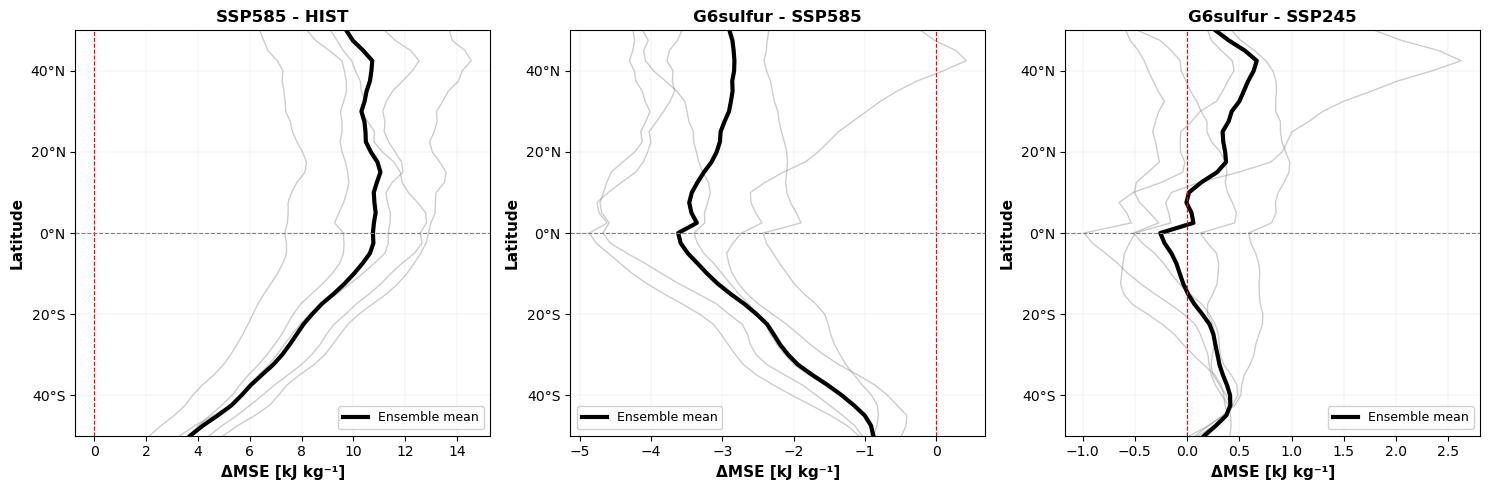

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Create figure with 3 panels
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# List of stored results and their labels
result_sets = [
    (all_results_585_HIST, "SSP585 - HIST", axes[0]),
    (all_results_G6sulfur_585, "G6sulfur - SSP585", axes[1]),
    (all_results_G6sulfur_245, "G6sulfur - SSP245", axes[2])
]

for all_results, title, ax in result_sets:
    # Plot individual model differences (thin lines)
    all_diffs = []
    
    for model_name, results in all_results.items():
        exp_keys = list(results.keys())
        if len(exp_keys) >= 2:
            EXP1 = exp_keys[0]
            EXP2 = exp_keys[1]
            
            if EXP1 in results and EXP2 in results:
                # Get the mean MSE for both experiments
                mean1_SUM = roll_lon(regrid_to_common(results[EXP1]["SUM"]["mean"], target_lat=50))
                mean1_WIN = roll_lon(regrid_to_common(results[EXP1]["WIN"]["mean"], target_lat=50))
                mean2_SUM = roll_lon(regrid_to_common(results[EXP2]["SUM"]["mean"], target_lat=50))
                mean2_WIN = roll_lon(regrid_to_common(results[EXP2]["WIN"]["mean"], target_lat=50))
                
                lat = mean1_SUM.lat.values
                
                # Stitch: NH=SUM, SH=WIN
                mean1 = xr.where(mean1_SUM.lat > 0, mean1_SUM, mean1_WIN)
                mean2 = xr.where(mean2_SUM.lat > 0, mean2_SUM, mean2_WIN)
                
                # Zonal mean difference
                diff = mean1 - mean2
                zonal_diff = diff.mean(dim='lon') / 1000.0  # Convert to kJ
                
                # Plot individual model
                ax.plot(zonal_diff, lat, color='gray', alpha=0.4, linewidth=1.0)
                
                all_diffs.append(diff)
    
    # Compute and plot ensemble mean
    if all_diffs:
        ensemble_diff = xr.concat(all_diffs, dim='model').mean(dim='model')
        zonal_ensemble_diff = ensemble_diff.mean(dim='lon') / 1000.0
        
        ax.plot(zonal_ensemble_diff, lat, color='black', linewidth=3.0, 
                label='Ensemble mean')
    
    # Formatting
    ax.axvline(0, color='red', linewidth=0.8, linestyle='--')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_xlabel('ΔMSE [kJ kg⁻¹]', fontsize=11, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, linewidth=0.3, alpha=0.4)
    ax.legend(fontsize=9, loc='best', framealpha=0.9)
    ax.set_ylim(lat.min(), lat.max())
    ax.yaxis.set_major_formatter(plt.FuncFormatter(
        lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))

plt.tight_layout()
# plt.savefig('zonal_mean_diff_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# One panel plot

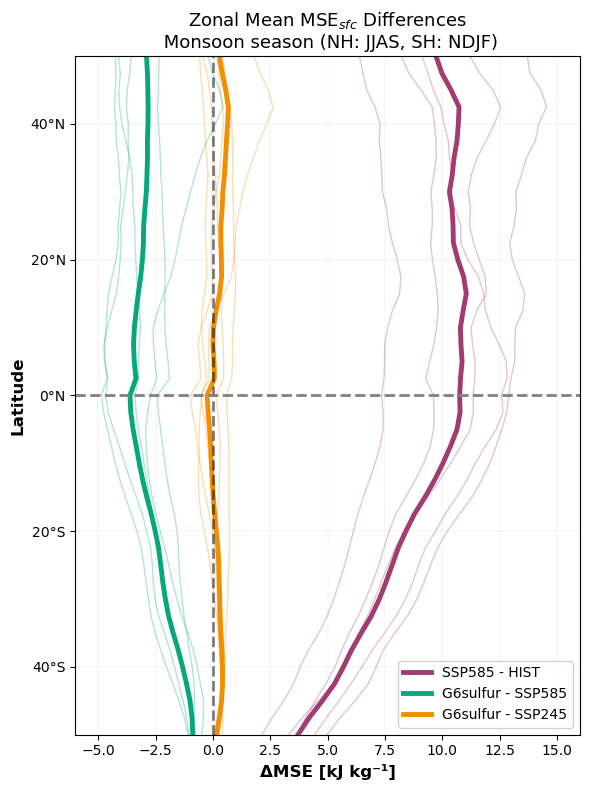

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

fig, ax = plt.subplots(figsize=(6, 8))

# List of stored results and their labels with colors
result_sets = [
    (all_results_585_HIST, "SSP585 - HIST", '#A23B72'),      # Purple-red
    (all_results_G6sulfur_585, "G6sulfur - SSP585", '#06A77D'),  # Green
    (all_results_G6sulfur_245, "G6sulfur - SSP245", '#F18F01')   # Orange
]

for all_results, label, color in result_sets:
    # Plot individual model differences (thin transparent lines)
    all_diffs = []
    
    for model_name, results in all_results.items():
        exp_keys = list(results.keys())
        if len(exp_keys) >= 2:
            EXP1 = exp_keys[0]
            EXP2 = exp_keys[1]
            
            if EXP1 in results and EXP2 in results:
                # Get the mean MSE for both experiments
                mean1_SUM = roll_lon(regrid_to_common(results[EXP1]["SUM"]["mean"], target_lat=50))
                mean1_WIN = roll_lon(regrid_to_common(results[EXP1]["WIN"]["mean"], target_lat=50))
                mean2_SUM = roll_lon(regrid_to_common(results[EXP2]["SUM"]["mean"], target_lat=50))
                mean2_WIN = roll_lon(regrid_to_common(results[EXP2]["WIN"]["mean"], target_lat=50))
                
                lat = mean1_SUM.lat.values
                
                # Stitch: NH=SUM, SH=WIN
                mean1 = xr.where(mean1_SUM.lat > 0, mean1_SUM, mean1_WIN)
                mean2 = xr.where(mean2_SUM.lat > 0, mean2_SUM, mean2_WIN)
                
                # Zonal mean difference
                diff = mean1 - mean2
                zonal_diff = diff.mean(dim='lon') / 1000.0  # Convert to kJ
                
                # Plot individual model (thin transparent)
                ax.plot(zonal_diff, lat, color=color, alpha=0.3, linewidth=1.0)
                
                all_diffs.append(diff)
    
    # Compute and plot ensemble mean (thick line)
    if all_diffs:
        ensemble_diff = xr.concat(all_diffs, dim='model').mean(dim='model')
        zonal_ensemble_diff = ensemble_diff.mean(dim='lon') / 1000.0
        
        ax.plot(zonal_ensemble_diff, lat, color=color, linewidth=3.5, 
                label=label, alpha=1.0)

# Formatting
ax.axvline(0, color='black', linewidth=2.0, linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', linewidth=2.0, linestyle='--')
ax.set_xlabel('ΔMSE [kJ kg⁻¹]', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title('Zonal Mean MSE$_{sfc}$ Differences\n Monsoon season (NH: JJAS, SH: NDJF)', fontsize=13, fontweight='normal')
ax.grid(True, linewidth=0.3, alpha=0.4)
ax.legend(fontsize=10, loc='best', framealpha=0.9)
ax.set_ylim(lat.min(), lat.max())
ax.set_xlim(-6, 16)
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('zonal_mean_diff_all.png', dpi=150, bbox_inches='tight')
plt.show()